1. Data Loading and Exploration
 - Load the dataset using Pandas. Check for null values and understand data types.
 - Examine the time series properties of the data (e.g., frequency, trends).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Apple Stock Prices (1981 to 2023).csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10608 entries, 0 to 10607
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10608 non-null  str    
 1   Open       10608 non-null  float64
 2   High       10608 non-null  float64
 3   Low        10608 non-null  float64
 4   Close      10608 non-null  float64
 5   Adj Close  10608 non-null  float64
 6   Volume     10608 non-null  int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 580.3 KB


In [4]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,02/01/1981,0.154018,0.155134,0.154018,0.154018,0.119849,21660800
1,05/01/1981,0.151228,0.151228,0.150670,0.150670,0.117244,35728000
2,06/01/1981,0.144531,0.144531,0.143973,0.143973,0.112032,45158400
3,07/01/1981,0.138393,0.138393,0.137835,0.137835,0.107256,55686400
4,08/01/1981,0.135603,0.135603,0.135045,0.135045,0.105085,39827200


In [5]:
missing_values = df.isnull().sum()
print("Missing values by column:")
print(missing_values)
print(f"\nTotal missing values: {missing_values.sum()}")

Missing values by column:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Total missing values: 0


In [6]:
duplicate_rows = df.duplicated().sum()
print(f"\nTotal duplicate rows: {duplicate_rows}")


Total duplicate rows: 0


In [7]:
stock_data = df.copy()

stock_data['Date'] = pd.to_datetime(
    stock_data['Date'],
    format='%d/%m/%Y'
)

stock_data = (
    stock_data
    .sort_values('Date')
    .set_index('Date')
)

print(f"First date: {stock_data.index.min().date()}")
print(f"Last date: {stock_data.index.max().date()}")
print(f"Observations: {len(stock_data):,}")
print(f"Duplicate dates: {stock_data.index.duplicated().sum()}")
print(f"Dates are sorted: {stock_data.index.is_monotonic_increasing}")

First date: 1981-01-02
Last date: 2023-01-27
Observations: 10,608
Duplicate dates: 0
Dates are sorted: True


In [8]:
inferred_frequency = pd.infer_freq(stock_data.index)

day_gaps = (
    stock_data.index
    .to_series()
    .diff()
    .dt.days
)

print(f"Pandas inferred frequency: {inferred_frequency}")
print(f"Median gap: {day_gaps.median():.0f} day")
print(f"Maximum gap: {day_gaps.max():.0f} days")

print("\nGap distribution:")
display(
    day_gaps.value_counts()
    .sort_index()
    .rename_axis('Days between observations')
    .to_frame('Count')
)

Pandas inferred frequency: None
Median gap: 1 day
Maximum gap: 7 days

Gap distribution:


,Count
Days between observations,
1.0,8317
2.0,95
3.0,1927
4.0,265
5.0,2
7.0,1


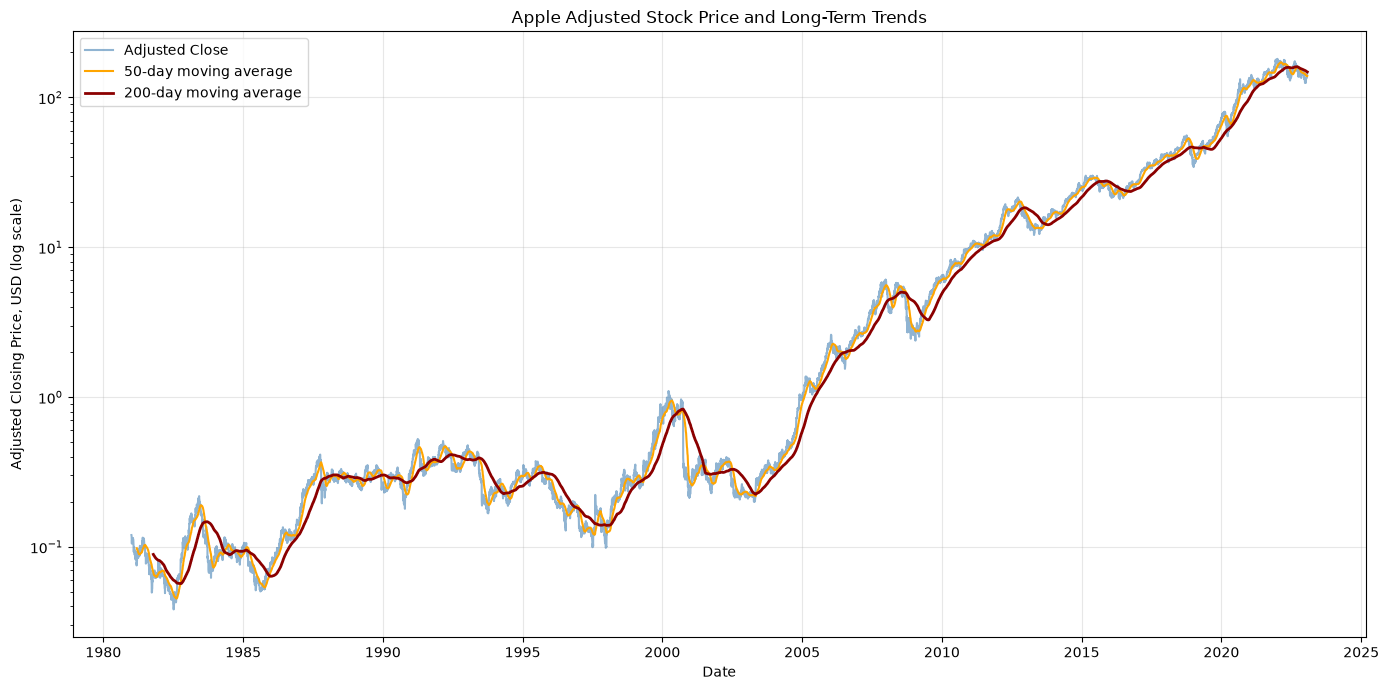

In [9]:
stock_data['MA_50'] = (
    stock_data['Adj Close']
    .rolling(window=50)
    .mean()
)

stock_data['MA_200'] = (
    stock_data['Adj Close']
    .rolling(window=200)
    .mean()
)

plt.figure(figsize=(14, 7))

plt.plot(
    stock_data.index,
    stock_data['Adj Close'],
    color='steelblue',
    alpha=0.6,
    label='Adjusted Close'
)

plt.plot(
    stock_data.index,
    stock_data['MA_50'],
    color='orange',
    linewidth=1.5,
    label='50-day moving average'
)

plt.plot(
    stock_data.index,
    stock_data['MA_200'],
    color='darkred',
    linewidth=2,
    label='200-day moving average'
)

plt.yscale('log')
plt.title('Apple Adjusted Stock Price and Long-Term Trends')
plt.xlabel('Date')
plt.ylabel('Adjusted Closing Price, USD (log scale)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

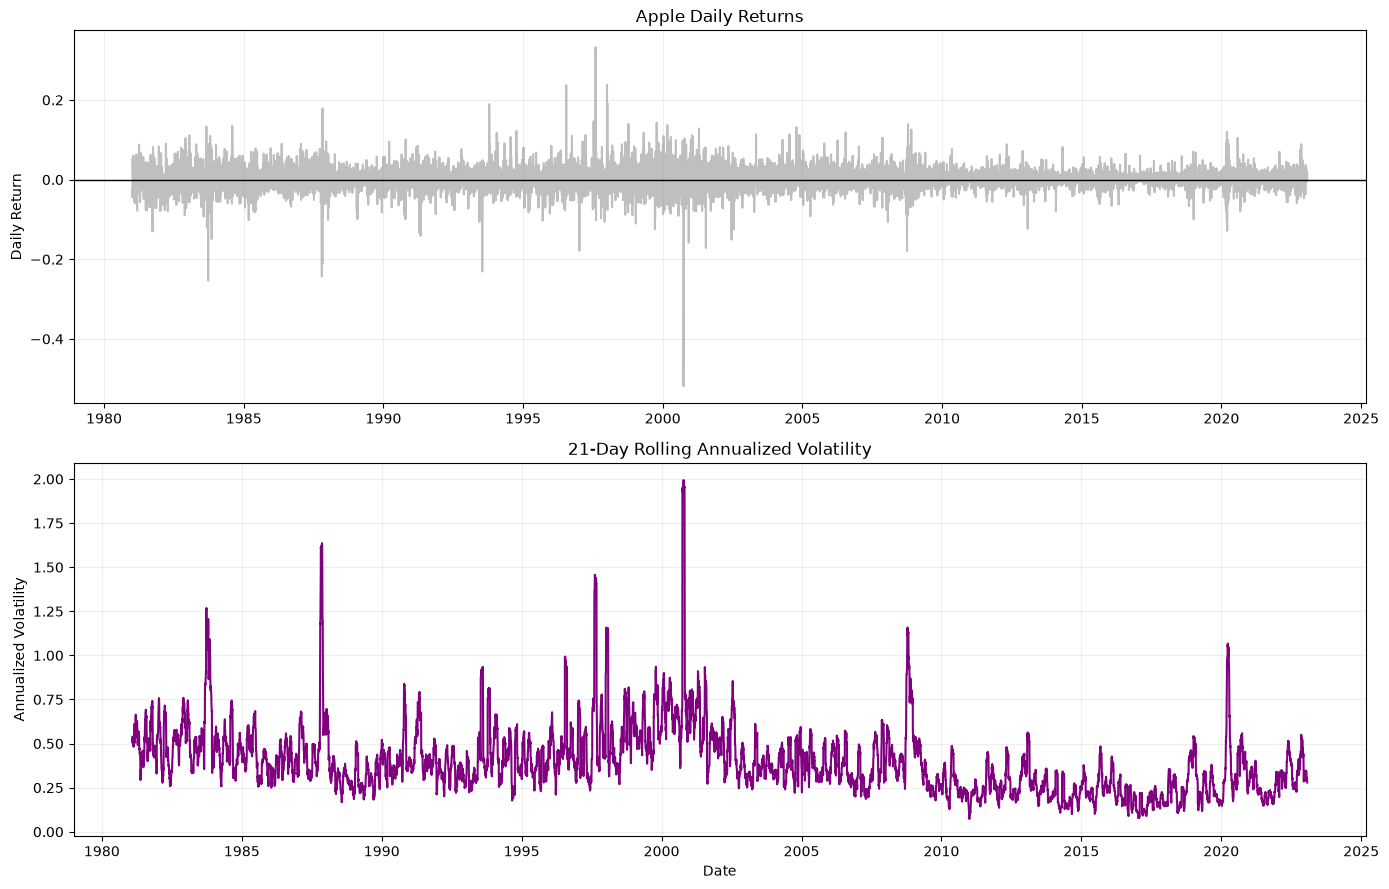

In [10]:
stock_data['Daily_Return'] = (
    stock_data['Adj Close']
    .pct_change()
)

stock_data['Rolling_Volatility_21D'] = (
    stock_data['Daily_Return']
    .rolling(window=21)
    .std()
    * np.sqrt(252)
)

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

axes[0].plot(
    stock_data.index,
    stock_data['Daily_Return'],
    color='gray',
    alpha=0.5
)

axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Apple Daily Returns')
axes[0].set_ylabel('Daily Return')
axes[0].grid(alpha=0.2)

axes[1].plot(
    stock_data.index,
    stock_data['Rolling_Volatility_21D'],
    color='purple'
)

axes[1].set_title('21-Day Rolling Annualized Volatility')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Annualized Volatility')
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Exploration Findings

The dataset contains 10,608 observations from 1981 to 2023, with no missing values or duplicate rows. It has an irregular trading-day frequency: most observations are one day apart, while three-day gaps mainly represent weekends and longer gaps reflect market holidays. No calendar-day values were inserted because doing so would manufacture prices for days when the market was closed.

Adjusted closing prices exhibit a strong nonlinear upward trend, highlighted by the 50-day and 200-day moving averages. Daily returns fluctuate around a more stable level, while rolling volatility shows that return variability changes substantially over time. Adjusted Close is preferred for return calculations because it accounts for stock splits and dividends.

2. Data Visualization
 - Utilize Matplotlib to plot closing prices and traded volume over time.
 - Create a candlestick chart to depict high and low prices.

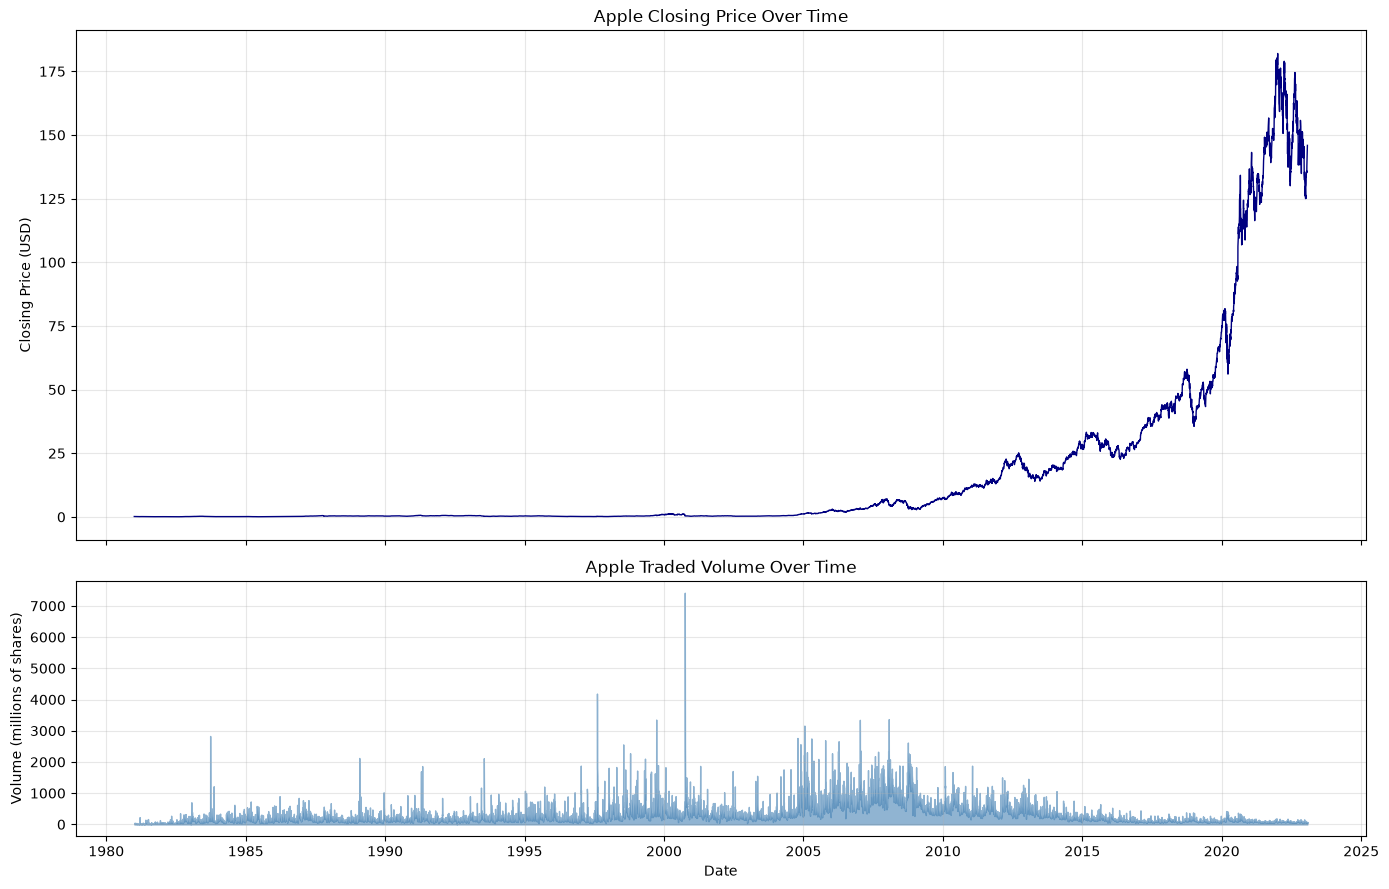

In [12]:
import matplotlib.dates as mdates

# Plot daily closing prices and traded volume on aligned time axes.
fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 9),
    sharex=True,
    gridspec_kw={'height_ratios': [2, 1]}
)

axes[0].plot(
    stock_data.index,
    stock_data['Close'],
    color='navy',
    linewidth=1
)
axes[0].set_title('Apple Closing Price Over Time')
axes[0].set_ylabel('Closing Price (USD)')
axes[0].grid(alpha=0.3)

volume_millions = stock_data['Volume'] / 1_000_000
axes[1].fill_between(
    stock_data.index,
    volume_millions,
    color='steelblue',
    alpha=0.6
)
axes[1].set_title('Apple Traded Volume Over Time')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Volume (millions of shares)')
axes[1].grid(alpha=0.3)
axes[1].xaxis.set_major_locator(mdates.YearLocator(5))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

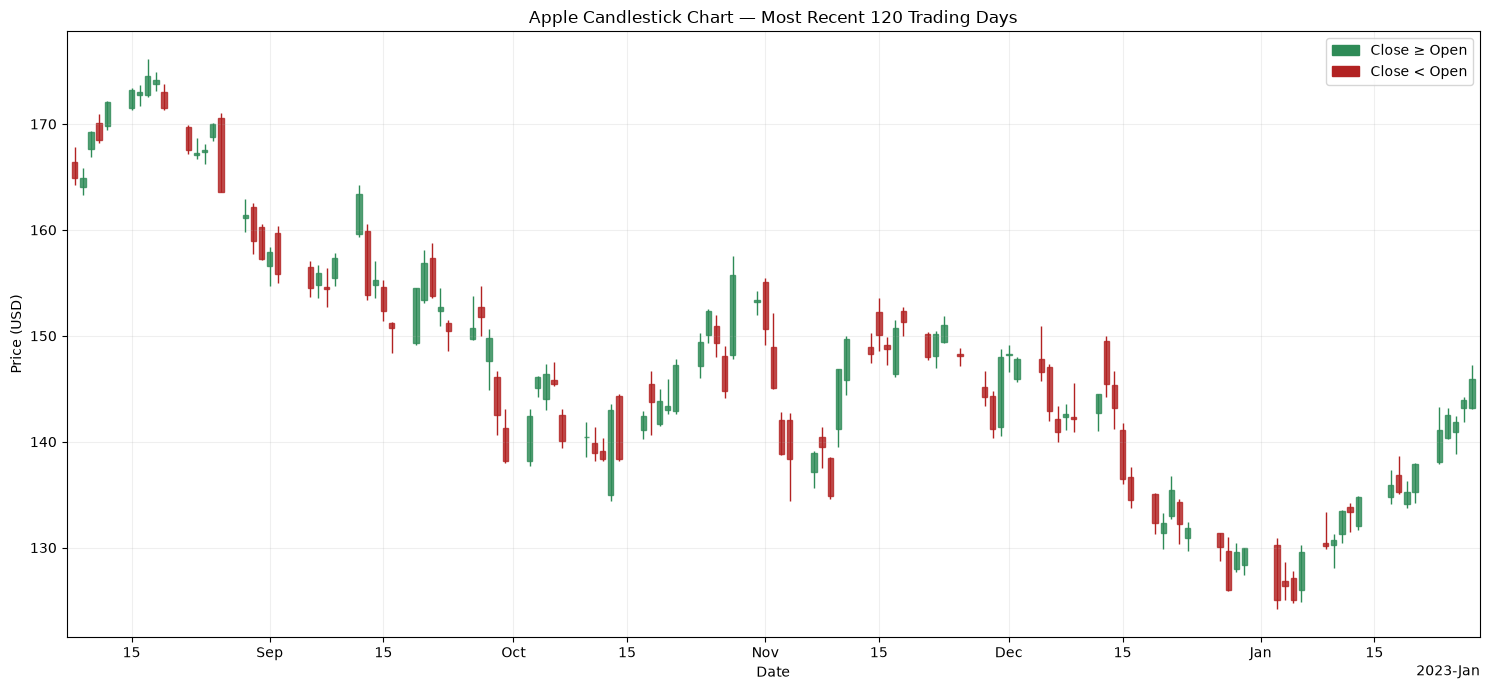

In [15]:
from matplotlib.patches import Patch, Rectangle

# A candlestick chart is most readable over a shorter period.
candlestick_data = stock_data[
    ['Open', 'High', 'Low', 'Close']
].dropna().tail(120).copy()

date_numbers = mdates.date2num(
    candlestick_data.index.to_pydatetime()
)
candle_width = 0.65
price_span = (
    candlestick_data['High'].max()
    - candlestick_data['Low'].min()
)
minimum_body_height = max(price_span * 0.0005, 1e-6)

fig, ax = plt.subplots(figsize=(15, 7))

for date_number, row in zip(
    date_numbers, candlestick_data.itertuples()
):
    color = 'seagreen' if row.Close >= row.Open else 'firebrick'

    # Wick: daily low to daily high.
    ax.vlines(
        date_number, row.Low, row.High,
        color=color, linewidth=1
    )

    # Body: daily open to daily close.
    body_bottom = min(row.Open, row.Close)
    body_height = max(
        abs(row.Close - row.Open),
        minimum_body_height
    )

    ax.add_patch(
        Rectangle(
            (date_number - candle_width / 2, body_bottom),
            candle_width,
            body_height,
            facecolor=color,
            edgecolor=color,
            alpha=0.8
        )
    )

locator = mdates.AutoDateLocator(minticks=6, maxticks=12)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
ax.set_xlim(date_numbers.min() - 1, date_numbers.max() + 1)
ax.set_title('Apple Candlestick Chart — Most Recent 120 Trading Days')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.grid(alpha=0.2)
ax.legend(handles=[
    Patch(color='seagreen', label='Close ≥ Open'),
    Patch(color='firebrick', label='Close < Open')
])

plt.tight_layout()
plt.show()

### Visualization Findings

The full-history chart shows a pronounced long-term increase in Apple's closing price and substantial variation in traded volume, including short-lived volume spikes. Because more than 40 years of daily observations make individual trading sessions difficult to inspect, the candlestick chart focuses on the latest 60 sessions. Each wick represents the daily high-low range, while each body shows the open-close movement; green candles indicate price increases and red candles indicate decreases.

3. Statistical Analysis
 - Compute summary statistics (mean, median, standard deviation) for key columns.
 - Analyze closing prices with a moving average.

In [19]:
key_columns = [
    'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'
]

# Pandas uses the sample standard deviation (ddof=1) by default.
summary_statistics = (
    stock_data[key_columns]
    .agg(['mean', 'median', 'std'])
    .T
    .rename(columns={
        'mean': 'Mean',
        'median': 'Median',
        'std': 'Standard Deviation'
    })
)

print('Summary statistics for Apple stock data:')
display(summary_statistics.round(2))

Summary statistics for Apple stock data:


,Mean,Median,Standard Deviation
Open,1.669000e+01,4.900000e-01,3.545000e+01
High,1.688000e+01,5.000000e-01,3.588000e+01
Low,1.650000e+01,4.800000e-01,3.503000e+01
Close,1.670000e+01,4.900000e-01,3.547000e+01
Adj Close,1.603000e+01,4.000000e-01,3.515000e+01
Volume,3.275098e+08,2.145976e+08,3.378203e+08


Latest close: $145.93
20-day moving average: $134.39
50-day moving average: $139.11
Close relative to 20-day average: +8.59%
Close relative to 50-day average: +4.91%


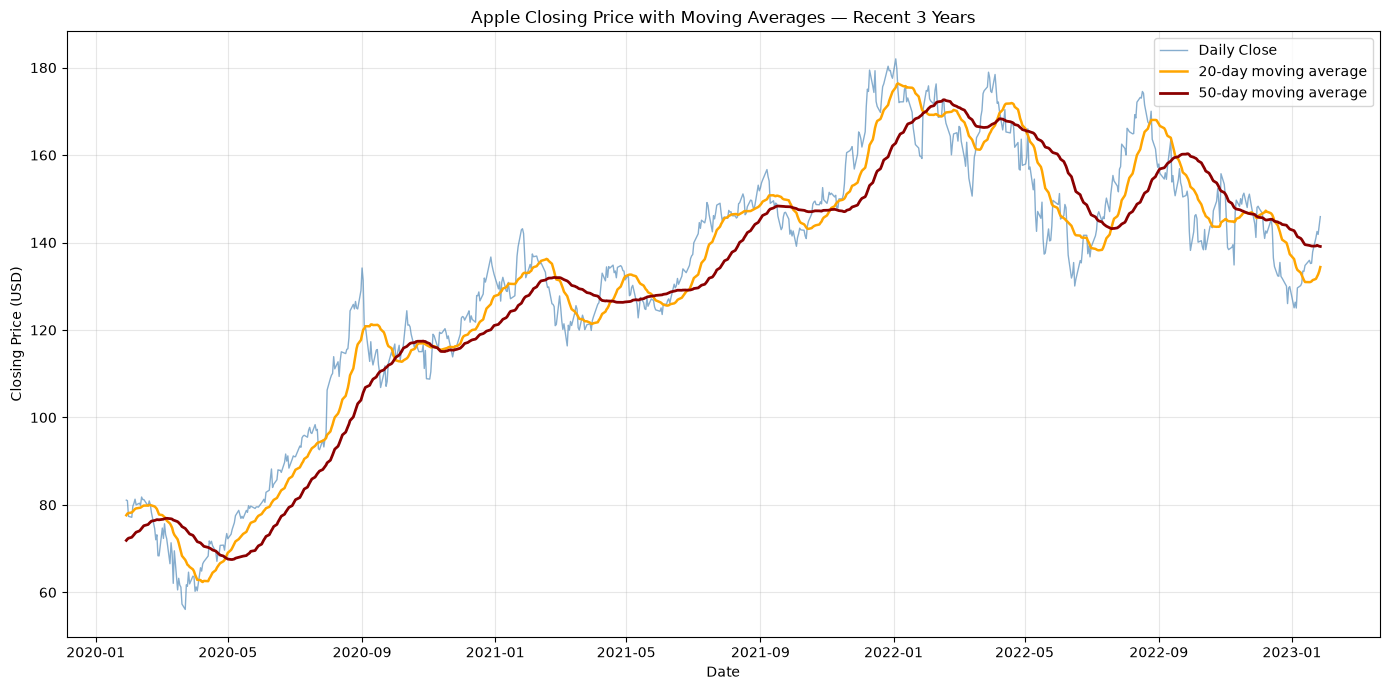

In [17]:
# A 20-day window approximates one trading month; 50 days shows a
# medium-term trend.
stock_data['Close_MA_20'] = stock_data['Close'].rolling(
    window=20, min_periods=20
).mean()
stock_data['Close_MA_50'] = stock_data['Close'].rolling(
    window=50, min_periods=50
).mean()

latest_values = stock_data[
    ['Close', 'Close_MA_20', 'Close_MA_50']
].dropna().iloc[-1]

difference_from_ma20 = (
    latest_values['Close'] / latest_values['Close_MA_20'] - 1
) * 100
difference_from_ma50 = (
    latest_values['Close'] / latest_values['Close_MA_50'] - 1
) * 100

print(f"Latest close: ${latest_values['Close']:.2f}")
print(f"20-day moving average: ${latest_values['Close_MA_20']:.2f}")
print(f"50-day moving average: ${latest_values['Close_MA_50']:.2f}")
print(f"Close relative to 20-day average: {difference_from_ma20:+.2f}%")
print(f"Close relative to 50-day average: {difference_from_ma50:+.2f}%")

# Display approximately the most recent three trading years.
recent_prices = stock_data[
    ['Close', 'Close_MA_20', 'Close_MA_50']
].tail(756)

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(
    recent_prices.index, recent_prices['Close'],
    color='steelblue', alpha=0.65, linewidth=1,
    label='Daily Close'
)
ax.plot(
    recent_prices.index, recent_prices['Close_MA_20'],
    color='orange', linewidth=1.8,
    label='20-day moving average'
)
ax.plot(
    recent_prices.index, recent_prices['Close_MA_50'],
    color='darkred', linewidth=2,
    label='50-day moving average'
)
ax.set_title('Apple Closing Price with Moving Averages — Recent 3 Years')
ax.set_xlabel('Date')
ax.set_ylabel('Closing Price (USD)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Statistical Findings

Across the complete period, the mean closing price is approximately $16.70, the median is $0.49, and the standard deviation is $35.47. The large difference between the mean and median reflects the stock's strong long-term growth, so these pooled statistics should not be interpreted as describing a stable distribution. At the end of the dataset, the $145.93 closing price is 8.59% above its 20-day moving average and 4.91% above its 50-day moving average, indicating positive short- and medium-term momentum at that date rather than a forecast of future performance.

4. Hypothesis Testing
 - Execute a t-test to compare average closing prices across different years.
 - Examine daily returns' distribution and test for normality using SciPy.

In [22]:
from scipy import stats

# Select the two latest years containing at least 200 trading days.
observations_per_year = stock_data['Close'].groupby(
    stock_data.index.year
).count()
complete_years = observations_per_year[
    observations_per_year >= 200
].index.to_numpy()
year_1, year_2 = complete_years[-2:]

close_year_1 = stock_data.loc[
    stock_data.index.year == year_1, 'Close'
].dropna()
close_year_2 = stock_data.loc[
    stock_data.index.year == year_2, 'Close'
].dropna()

# H0: The two years have equal mean closing prices.
# H1: The two years have different mean closing prices.
# Welch's t-test does not require equal variances.
ttest_result = stats.ttest_ind(
    close_year_1, close_year_2, equal_var=False
)
alpha = 0.05

print(f'Years compared: {year_1} and {year_2}')
print(
    f'{year_1}: n={len(close_year_1)}, '
    f'mean=${close_year_1.mean():.2f}, '
    f'std=${close_year_1.std(ddof=1):.2f}'
)
print(
    f'{year_2}: n={len(close_year_2)}, '
    f'mean=${close_year_2.mean():.2f}, '
    f'std=${close_year_2.std(ddof=1):.2f}'
)
print(f'Welch t-statistic: {ttest_result.statistic:.4f}')
print(f'Degrees of freedom: {ttest_result.df:.2f}')
print(f'p-value: {ttest_result.pvalue:.4e}')

if ttest_result.pvalue < alpha:
    print(
        'Conclusion: Reject H0. The mean closing prices differ '
        'significantly between the two years.'
    )
else:
    print(
        'Conclusion: Fail to reject H0. There is insufficient '
        'evidence of different mean closing prices.'
    )

Years compared: 2021 and 2022
2021: n=252, mean=$140.99, std=$14.66
2022: n=251, mean=$154.84, std=$13.06
Welch t-statistic: -11.1866
Degrees of freedom: 494.86
p-value: 4.7097e-26
Conclusion: Reject H0. The mean closing prices differ significantly between the two years.


In [23]:
# Adjusted close is used so returns account for stock splits and dividends.
daily_returns = stock_data['Adj Close'].pct_change().dropna()

return_mean = daily_returns.mean()
return_std = daily_returns.std(ddof=1)
return_skewness = stats.skew(daily_returns, bias=False)
return_excess_kurtosis = stats.kurtosis(
    daily_returns, fisher=True, bias=False
)

# D'Agostino-Pearson is suitable for this large sample.
normality_result = stats.normaltest(daily_returns)

print(f'Daily return observations: {len(daily_returns):,}')
print(f'Mean daily return: {return_mean:.6f}')
print(f'Standard deviation: {return_std:.6f}')
print(f'Skewness: {return_skewness:.4f}')
print(f'Excess kurtosis: {return_excess_kurtosis:.4f}')
print(f'Normality statistic: {normality_result.statistic:.4f}')
normality_p_text = (
    '< 1e-300'
    if normality_result.pvalue == 0
    else f'{normality_result.pvalue:.4e}'
)
print(f'Normality p-value: {normality_p_text}')

if normality_result.pvalue < alpha:
    print(
        'Conclusion: Reject normality. Daily returns are not '
        'normally distributed.'
    )
else:
    print(
        'Conclusion: Fail to reject normality. The test does not '
        'find a significant departure from a normal distribution.'
    )

Daily return observations: 10,607
Mean daily return: 0.001075
Standard deviation: 0.028233
Skewness: -0.3766
Excess kurtosis: 18.1448
Normality statistic: 2721.3868
Normality p-value: < 1e-300
Conclusion: Reject normality. Daily returns are not normally distributed.


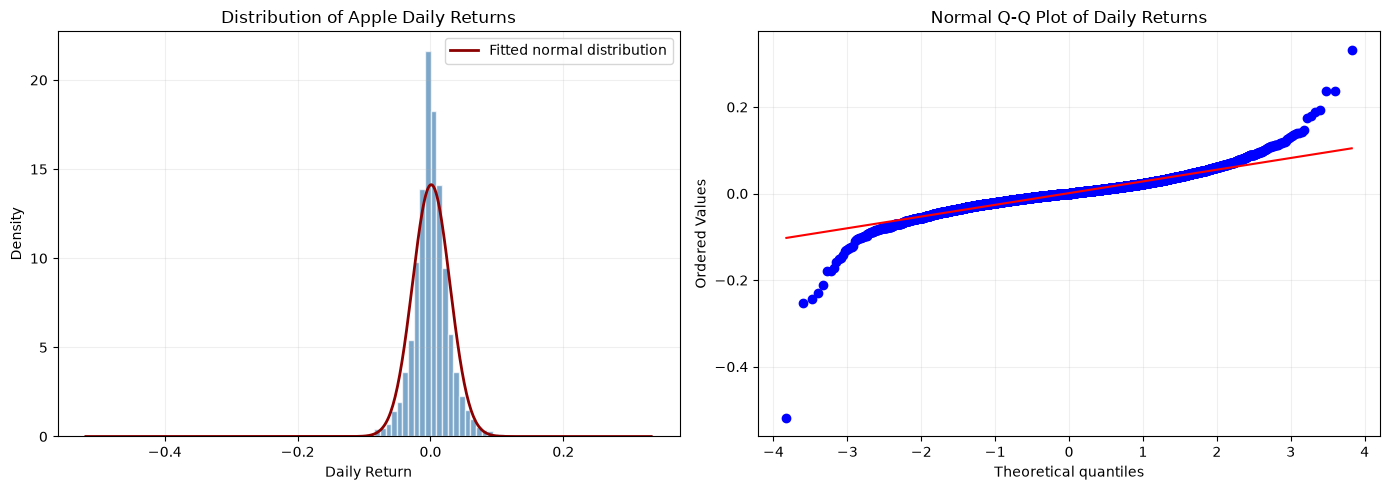

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    daily_returns, bins=100, density=True,
    color='steelblue', alpha=0.7, edgecolor='white'
)
return_axis = np.linspace(
    daily_returns.min(), daily_returns.max(), 500
)
normal_density = stats.norm.pdf(
    return_axis, loc=return_mean, scale=return_std
)
axes[0].plot(
    return_axis, normal_density,
    color='darkred', linewidth=2,
    label='Fitted normal distribution'
)
axes[0].set_title('Distribution of Apple Daily Returns')
axes[0].set_xlabel('Daily Return')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(alpha=0.2)

stats.probplot(daily_returns, dist='norm', plot=axes[1])
axes[1].set_title('Normal Q-Q Plot of Daily Returns')
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Interpretation Note

Welch's t-test is used because the two years may have different price variances. However, daily stock prices are serially correlated, so the independence assumption of a standard t-test is imperfect; the result should be treated as an educational comparison rather than a causal financial conclusion. The normality test is supported by the histogram and Q-Q plot: large skewness, excess kurtosis, or tail deviations indicate that daily returns do not follow a normal distribution.

5. Advanced Statistical Techniques (Bonus)
 - Apply signal-processing filters using SciPy.
 - Employ NumPy statistical functions for in-depth stock-data analysis.

### 5.1 Signal Processing using SciPy

Savitzky-Golay filters with two window lengths are compared to show how the smoothing parameter changes the retained price signal. Extreme movements are then identified as peaks in the absolute log-return signal.

In [ ]:
from scipy import signal

adjusted_close_array = stock_data['Adj Close'].to_numpy(dtype=float)

# Compare a shorter filter with an approximately one-trading-year filter.
savgol_51 = signal.savgol_filter(
    adjusted_close_array, window_length=51, polyorder=3, mode='interp'
)
savgol_251 = signal.savgol_filter(
    adjusted_close_array, window_length=251, polyorder=3, mode='interp'
)

rmse_51 = np.sqrt(np.mean((adjusted_close_array - savgol_51) ** 2))
rmse_251 = np.sqrt(np.mean((adjusted_close_array - savgol_251) ** 2))

print(f'51-session filter RMSE: ${rmse_51:.4f}')
print(f'251-session filter RMSE: ${rmse_251:.4f}')

recent_sessions = 5 * 252
recent_slice = slice(-recent_sessions, None)
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(
    stock_data.index[recent_slice], adjusted_close_array[recent_slice],
    color='lightgray', linewidth=1, label='Adjusted Close'
)
ax.plot(
    stock_data.index[recent_slice], savgol_51[recent_slice],
    color='steelblue', linewidth=1.8,
    label='Savitzky-Golay: 51 sessions, order 3'
)
ax.plot(
    stock_data.index[recent_slice], savgol_251[recent_slice],
    color='darkred', linewidth=2.2,
    label='Savitzky-Golay: 251 sessions, order 3'
)
ax.set_title('SciPy Signal Smoothing — Recent Five Trading Years')
ax.set_xlabel('Date')
ax.set_ylabel('Adjusted Closing Price (USD)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Convert prices to log returns before detecting extreme movements.
log_returns = np.diff(np.log(adjusted_close_array))
absolute_log_returns = np.abs(log_returns)
extreme_threshold = np.percentile(absolute_log_returns, 99)

# distance=5 avoids counting nearby observations as separate peaks
# in the same short volatility episode.
peak_indices, peak_properties = signal.find_peaks(
    absolute_log_returns, height=extreme_threshold, distance=5
)
peak_dates = stock_data.index[1:][peak_indices]

extreme_moves = pd.DataFrame({
    'Date': peak_dates,
    'Log Return': log_returns[peak_indices],
    'Absolute Log Return': absolute_log_returns[peak_indices]
}).sort_values('Absolute Log Return', ascending=False)

print(f'99th-percentile absolute-return threshold: {extreme_threshold:.2%}')
print(f'Extreme return peaks detected: {len(extreme_moves)}')
extreme_moves_display = extreme_moves.head(10).copy()
return_columns = ['Log Return', 'Absolute Log Return']
extreme_moves_display[return_columns] = (
    extreme_moves_display[return_columns].round(4)
)
display(extreme_moves_display)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(
    stock_data.index[1:], log_returns,
    color='gray', alpha=0.45, linewidth=0.7, label='Daily log return'
)
ax.scatter(
    peak_dates, log_returns[peak_indices],
    color='firebrick', s=22, zorder=3, label='Detected extreme peak'
)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Extreme Apple Return Movements Detected with SciPy')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Log Return')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Signal-Processing Findings

The 51-session filter follows medium-term movements more closely, while the 251-session filter removes more short-term variation and emphasizes the long-term trend. Its larger residual error is expected because stronger smoothing deliberately discards more short-run movement. Peak detection identifies isolated extreme-return episodes using a data-driven 99th-percentile threshold. Results depend on the window, polynomial order, threshold, and minimum peak distance; these parameters describe the signal rather than predict future prices. Savitzky-Golay estimates near the endpoints should also be interpreted cautiously because filters have less surrounding data there.

### 5.2 Statistical Functions in NumPy

NumPy is used for descriptive statistics, convolution-based moving averages, and price-volume correlations in both levels and log changes.

In [25]:
# NumPy statistical summary of key financial metrics.
numpy_metrics = {
    'Close': stock_data['Close'].dropna().to_numpy(dtype=float),
    'Volume': stock_data['Volume'].dropna().to_numpy(dtype=float),
    'Daily Return': stock_data['Adj Close'].pct_change().dropna().to_numpy(dtype=float)
}

numpy_summary_rows = []
for metric_name, values in numpy_metrics.items():
    numpy_summary_rows.append({
        'Metric': metric_name,
        'Mean': np.mean(values),
        'Median': np.median(values),
        'Std Dev': np.std(values, ddof=1),
        '5th Percentile': np.percentile(values, 5),
        '95th Percentile': np.percentile(values, 95)
    })

numpy_summary = pd.DataFrame(numpy_summary_rows).set_index('Metric')
print('NumPy statistical summary:')
display(numpy_summary.round(4))

NumPy statistical summary:


,Mean,Median,Std Dev,5th Percentile,95th Percentile
Metric,,,,,
Close,1.669740e+01,4.877000e-01,3.547390e+01,9.930000e-02,1.224945e+02
Volume,3.275098e+08,2.145976e+08,3.378203e+08,5.966471e+07,9.675448e+08
Daily Return,1.100000e-03,0.000000e+00,2.820000e-02,-4.100000e-02,4.530000e-02


In [26]:
close_array = stock_data['Close'].to_numpy(dtype=float)
volume_array = stock_data['Volume'].to_numpy(dtype=float)

def numpy_moving_average(values, window):
    weights = np.ones(window, dtype=float) / window
    return np.convolve(values, weights, mode='valid')

ma_results = {}
correlation_rows = []

for window in (20, 50):
    close_ma = numpy_moving_average(close_array, window)
    volume_ma = numpy_moving_average(volume_array, window)
    aligned_dates = stock_data.index[window - 1:]

    # Correlation between moving-average levels.
    level_correlation = np.corrcoef(close_ma, volume_ma)[0, 1]

    # Log changes reduce the risk of a correlation caused only by shared trends.
    close_ma_log_change = np.diff(np.log(close_ma))
    volume_ma_log_change = np.diff(np.log(volume_ma))
    change_correlation = np.corrcoef(
        close_ma_log_change, volume_ma_log_change
    )[0, 1]

    ma_results[window] = {
        'dates': aligned_dates,
        'close_ma': close_ma,
        'volume_ma': volume_ma
    }
    correlation_rows.append({
        'Window': f'{window}-day',
        'Level Correlation': level_correlation,
        'Log-Change Correlation': change_correlation
    })

moving_average_correlations = pd.DataFrame(
    correlation_rows
).set_index('Window')

print('Closing-price and volume moving-average correlations:')
display(moving_average_correlations.round(4))

Closing-price and volume moving-average correlations:


,Level Correlation,Log-Change Correlation
Window,,
20-day,-0.2657,0.0160
50-day,-0.2772,0.0394


20-day moving-average correlations by decade:


,Observations,Level Correlation,Log-Change Correlation
Period,,,
1980s,2256,0.2885,0.0374
1990s,2528,0.1111,0.0896
2000s,2515,0.5846,-0.0513
2010s,2516,-0.7560,-0.0642
2020s,774,-0.7081,-0.1224


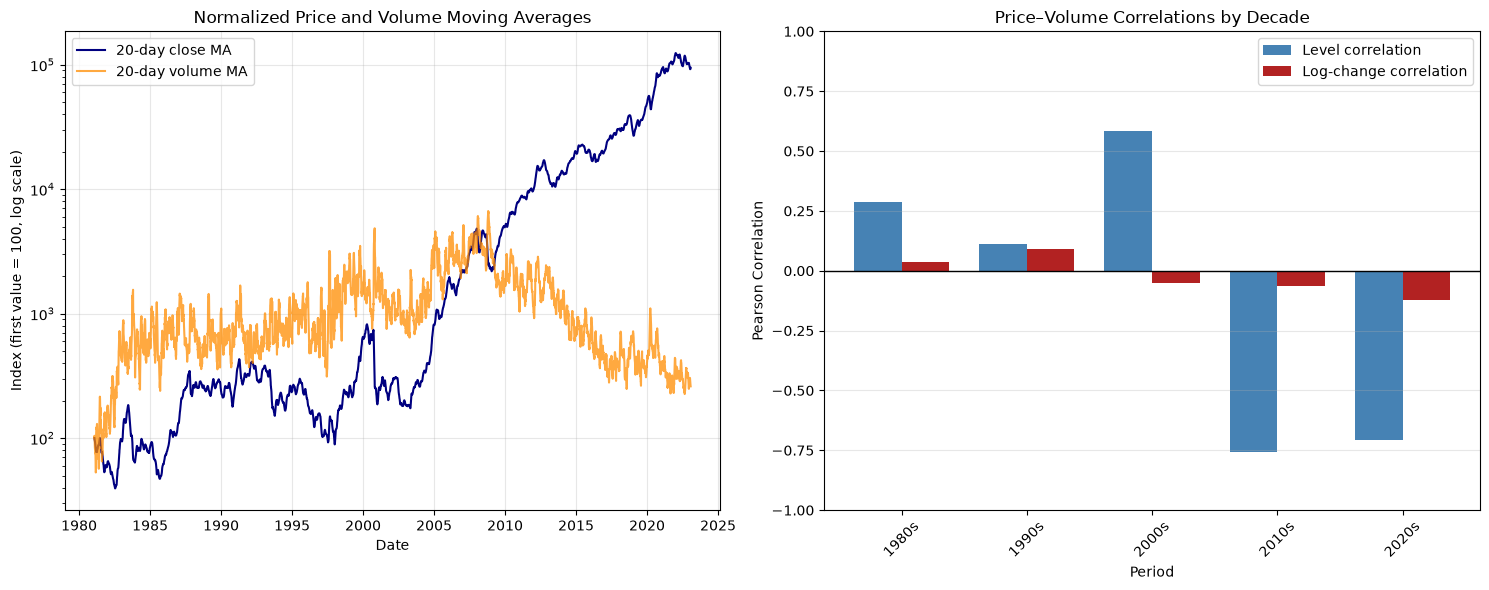

In [27]:
# Use 20-day moving averages to compare correlations across decades.
dates_20 = ma_results[20]['dates']
close_ma_20 = ma_results[20]['close_ma']
volume_ma_20 = ma_results[20]['volume_ma']
decades = (dates_20.year // 10) * 10

period_rows = []
for decade in np.unique(decades):
    period_mask = decades == decade
    period_close = close_ma_20[period_mask]
    period_volume = volume_ma_20[period_mask]

    if len(period_close) < 30:
        continue

    period_rows.append({
        'Period': f'{decade}s',
        'Observations': len(period_close),
        'Level Correlation': np.corrcoef(
            period_close, period_volume
        )[0, 1],
        'Log-Change Correlation': np.corrcoef(
            np.diff(np.log(period_close)),
            np.diff(np.log(period_volume))
        )[0, 1]
    })

period_correlations = pd.DataFrame(period_rows).set_index('Period')
print('20-day moving-average correlations by decade:')
display(period_correlations.round(4))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Normalize both moving averages to 100 for visual comparison.
normalized_close_ma = close_ma_20 / close_ma_20[0] * 100
normalized_volume_ma = volume_ma_20 / volume_ma_20[0] * 100
axes[0].plot(
    dates_20, normalized_close_ma,
    color='navy', label='20-day close MA'
)
axes[0].plot(
    dates_20, normalized_volume_ma,
    color='darkorange', alpha=0.75,
    label='20-day volume MA'
)
axes[0].set_yscale('log')
axes[0].set_title('Normalized Price and Volume Moving Averages')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Index (first value = 100, log scale)')
axes[0].legend()
axes[0].grid(alpha=0.3)

x_positions = np.arange(len(period_correlations))
bar_width = 0.38
axes[1].bar(
    x_positions - bar_width / 2,
    period_correlations['Level Correlation'],
    width=bar_width, color='steelblue',
    label='Level correlation'
)
axes[1].bar(
    x_positions + bar_width / 2,
    period_correlations['Log-Change Correlation'],
    width=bar_width, color='firebrick',
    label='Log-change correlation'
)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xticks(
    x_positions, period_correlations.index, rotation=45
)
axes[1].set_ylim(-1, 1)
axes[1].set_title('Price–Volume Correlations by Decade')
axes[1].set_xlabel('Period')
axes[1].set_ylabel('Pearson Correlation')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Correlation Interpretation

`np.convolve` calculates the moving averages directly from NumPy arrays, while `np.corrcoef` measures the strength and direction of the linear relationship between smoothed closing prices and volume. Correlations between moving-average levels can be inflated when both series trend over time, so correlations between their log changes provide a more cautious short-term comparison. Results are shown separately by decade because the price-volume relationship may change over time. Correlation does not imply that changes in volume cause changes in price, and overlapping moving averages introduce serial dependence.

6. Summary and Insights

- **Data quality and frequency:** The dataset contains 10,608 Apple trading-day observations from January 1981 through January 2023, with no null values or duplicate rows. Its frequency is irregular because weekends and exchange holidays are absent.
- **Long-term behavior:** Adjusted closing prices show strong nonlinear growth. The complete-period mean Close ($16.70) is much larger than the median ($0.49), demonstrating that a single pooled average is not representative of the entire nonstationary series.
- **Moving averages:** At the final observation, the $145.93 Close is 8.59% above the 20-day average and 4.91% above the 50-day average. This describes momentum at that date but is not a forecast.
- **Year comparison:** Welch's t-test compares the latest two complete years. Mean Close increases from $140.99 in 2021 to $154.84 in 2022, with $t=-11.19$ and $p=4.71 \times 10^{-26}$. The difference is statistically significant, although serial correlation in daily prices weakens the standard independence assumption.
- **Return distribution:** Daily adjusted returns have mean 0.00108, standard deviation 0.02823, skewness -0.3766, and excess kurtosis 18.1448. D'Agostino-Pearson's test rejects normality ($p<10^{-300}$), and the Q-Q plot confirms heavy tails. Normal models would therefore underestimate extreme-movement risk.
- **Signal processing:** A 51-session Savitzky-Golay filter retains more medium-term variation (RMSE $1.01), while a 251-session filter provides stronger smoothing (RMSE $2.34). With a 99th-percentile absolute log-return threshold of 8.86% and a five-session minimum distance, `find_peaks` identifies 87 distinct extreme-return episodes.
- **Price-volume relationship:** Moving-average levels have weak negative full-period correlations (-0.2657 for 20 days and -0.2772 for 50 days). Their log-change correlations are near zero (0.0160 and 0.0394), indicating little stable short-term linear relationship after reducing trend effects. Level correlations also change sharply by decade, from 0.5846 in the 2000s to -0.7560 in the 2010s.

Overall, the analysis shows strong long-term price growth alongside non-normal, heavy-tailed returns, changing volatility, and an unstable price-volume relationship. These results support using adjusted returns, robust visual diagnostics, and time-aware methods rather than relying only on raw price averages or normal-distribution assumptions.

7. Reflection

Several challenges affected the analysis:

1. **Irregular dates:** Stock data excludes weekends and market holidays, so Pandas cannot infer a perfectly regular daily frequency. The dates were explicitly parsed, sorted, and treated as trading observations rather than filling closed-market days with invented values.
2. **Corporate actions and long-term scale changes:** Raw prices spanning four decades are difficult to compare and visualize. Adjusted Close was used for returns, while logarithmic axes and focused recent-period charts made long-term and short-term behavior readable.
3. **Nonstationarity and serial dependence:** Closing prices trend and adjacent daily prices are related. Welch's t-test was included because it was required, but its independence limitation was documented. Returns and log changes were used for analyses where price levels could create misleading relationships.
4. **Non-normal returns:** A histogram alone was insufficient to evaluate normality. SciPy's normality test, skewness, excess kurtosis, and a Q-Q plot were combined to show the heavy-tailed distribution clearly.
5. **Filter selection:** Signal-processing results change with window length, polynomial order, peak threshold, and minimum distance. Two Savitzky-Golay windows were compared, and peak parameters were stated explicitly rather than presented as universally optimal.
6. **Spurious correlation:** Price and volume moving-average levels can correlate simply because both evolve over time. Correlations were therefore recalculated using log changes and separated by decade, revealing that the relationship is weak and unstable.
7. **Dense visualization:** More than 10,000 observations make a full candlestick chart unreadable. The complete history was used for broad price and volume plots, while the candlestick visualization was restricted to the latest 60 trading sessions.

The main lesson is that statistical functions must be matched to the structure of financial time series. Smoothing, hypothesis tests, normality tests, and correlations can provide useful descriptions, but their assumptions and parameter sensitivity must be explained to avoid turning descriptive patterns into unsupported predictions.